#  案例实战：Phi-4 SFT 微调

In [1]:
import os
import json
import torch
import peft
import transformers
import numpy as np
import pandas as pd
from datasets import Dataset
import matplotlib.pyplot as plt
from peft import LoraConfig, TaskType, get_peft_model
from transformers import AutoModelForCausalLM, AutoTokenizer, TrainingArguments, Trainer, DataCollatorForSeq2Seq

In [2]:
print(torch.__version__)
print(peft.__version__)
print(transformers.__version__)

2.7.0+cu126
0.17.1
4.51.3


In [3]:
# 指令微调的提示词（可调整）

PROMPT = """你的角色：你是一位经验丰富的电商广告文案专家，尤其擅长撰写生动、吸引人且能促进销售的服装类商品描述。

任务：请根据用户提供的【关键词列表】，为一件商品创作一篇完整的广告文案。

背景信息与输入：
关键词：用户将提供一组由“属性#值”构成的关键词，详细描述了商品的类型、版型、风格、图案、款式等特征。

示例参考：
输入关键词：类型#上衣*版型#宽松*风格#街头*风格#休闲*风格#朋克*图案#字母*图案#文字*图案#印花*衣样式#卫衣*衣款式#连帽*衣款式#对称
输出文案示例：个性休闲风的连帽卫衣造型时髦大方，宽松的版型剪裁让肉肉的小宝贝也可以穿着，保暖的连帽设计时刻给予宝贝温柔的呵护，袖子和后背别致时髦的字母印花点缀，满满的街头元素融入，演绎休闲朋克风，对称的小口袋美观大方，方便放置更多的随身物品。

文案创作要求：
完整性：生成的文案必须是一段通顺、完整、可直接使用的商品描述段落。
信息整合：需要自然地涵盖并突出关键词中提供的所有核心属性（如版型、风格、图案、款式等），不能遗漏关键词和卖点。
语言风格：语言应 亲切、有感染力、具有销售力。适当使用引导语，描绘穿着场景和感受，激发购买欲望。
目标导向：文案的目的是促进销售，因此要突出商品的优势、解决用户的痛点（如“宽松版型”修饰身材）、并描绘穿着后的美好体验。

输出格式：
记住，只输出最终的广告文案，无需额外解释或输出其他内容。
"""

In [4]:
def process_func(example):
    """
    将数据集进行预处理
    """
    MAX_LENGTH = 1024 # 这个最大长度可以根据自己的数据来调整，可以先设置一个较大的数，tokenize完了之后再去统计一下token的长度分布
    input_ids, attention_mask, labels = [], [], []
    
    # 输入的模版
    instruction = tokenizer(
        f"<|system|>{PROMPT}<|end|><|user|>{example['prompt']}<|end|><|assistant|>",
        add_special_tokens=False,
    )
    response = tokenizer(f"{example['chosen']}", add_special_tokens=False)
    # 在末尾添加一个pad token id，代表文本结束
    input_ids = instruction["input_ids"] + response["input_ids"] + [tokenizer.pad_token_id]
    # mask都是1
    attention_mask = (
        instruction["attention_mask"] + response["attention_mask"] + [1]
    )
    # 把输入部分的tokens屏蔽掉，不计算loss，不能左移1位
    labels = [-100] * len(instruction["input_ids"]) + response["input_ids"] + [tokenizer.pad_token_id]

    # 按最大的上下文长度截断
    if len(input_ids) > MAX_LENGTH:
        input_ids = input_ids[:MAX_LENGTH]
        attention_mask = attention_mask[:MAX_LENGTH]
        labels = labels[:MAX_LENGTH]
        
    return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}   


In [5]:
# 加载模型权重
model_dir = "LLM-Research/Phi-4-mini-instruct/" 
tokenizer = AutoTokenizer.from_pretrained(model_dir, use_fast=False)
model = AutoModelForCausalLM.from_pretrained(model_dir, torch_dtype=torch.bfloat16)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [8]:
messages = [
    {"role": "system", "content": "你是一个优秀的聊天机器人，总是给我正确的回应！"},
    {"role": "user", "content": '你好'},
    {"role": "assistant", "content": 'hello'},
]
new_prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)
print('-'*100)
print(new_prompt)

----------------------------------------------------------------------------------------------------
<|system|>你是一个优秀的聊天机器人，总是给我正确的回应！<|end|><|user|>你好<|end|><|assistant|>hello<|end|><|assistant|>


In [7]:
print(model)

Phi3ForCausalLM(
  (model): Phi3Model(
    (embed_tokens): Embedding(200064, 3072, padding_idx=199999)
    (layers): ModuleList(
      (0-31): 32 x Phi3DecoderLayer(
        (self_attn): Phi3Attention(
          (o_proj): Linear(in_features=3072, out_features=3072, bias=False)
          (qkv_proj): Linear(in_features=3072, out_features=5120, bias=False)
        )
        (mlp): Phi3MLP(
          (gate_up_proj): Linear(in_features=3072, out_features=16384, bias=False)
          (down_proj): Linear(in_features=8192, out_features=3072, bias=False)
          (activation_fn): SiLU()
        )
        (input_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (post_attention_layernorm): Phi3RMSNorm((3072,), eps=1e-05)
        (resid_attn_dropout): Dropout(p=0.0, inplace=False)
        (resid_mlp_dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (norm): Phi3RMSNorm((3072,), eps=1e-05)
    (rotary_emb): Phi3RotaryEmbedding()
  )
  (lm_head): Linear(in_features=3072, out_features=20006

In [8]:
# 加载处理数据集
train_dataset_path = "data/train_dpo_final.json"
test_dataset_path = "data/test_dpo_final.json"

# 验证集的比例为5%，训练为95%
val_ratio = 0.05
total_df = pd.read_json(train_dataset_path, lines=True)
test_df = pd.read_json(test_dataset_path, lines=True)

train_df = total_df[int(len(total_df) * val_ratio):]
val_df = total_df[:int(len(total_df) * val_ratio)]

print("train size:", len(train_df))
print("eval size:", len(val_df))
print("test size:", len(test_df))

train size: 42642
eval size: 2244
test size: 1057


In [9]:
total_df

,prompt,chosen,rejected
0,类型#裤*版型#显瘦*风格#简约*裤型#直筒裤*裤款式#松紧带,这条简约风的直筒裤简直是显瘦宝藏！利落的直筒版型精准修饰腿型，不管是梨形身材还是担心腿粗的姐...,带着简约风格，出色的直筒裤款式，修长的显瘦版型，优雅的松紧带设计，完美修饰你的身形，让你轻松...
1,类型#裙*风格#通勤*风格#休闲*图案#线条*图案#印花*裙领型#圆领,这条圆领连衣裙简直是通勤休闲两相宜的宝藏单品！柔和的圆领设计贴合颈部曲线，穿着舒适不束缚，日...,迎接每日通勤的轻盈灵动，轻盈的休闲裙，设计融入优雅的线条和动感的印花图案，圆领款式让你细腰流...
2,类型#裙*风格#简约*风格#青春*图案#字母*图案#文字*裙型#网纱裙*裙袖长#无袖*裙领型#圆领,这款简约青春风的无袖圆领网纱裙，简直是夏日少女的元气担当！轻盈的网纱裙身自带梦幻氛围感，走动...,轻盈的网纱裙轻轻卷曲，简约的青春风格与简洁的文字图案交织，圆领设计简约而优雅，裙袖长款式让你...
3,类型#裙*版型#h*材质#棉*风格#简约*风格#知性,这条棉质H型连衣裙简直是知性女性的衣橱宝藏！精选柔软亲肤的纯棉面料，透气舒适又亲肤，贴身穿像...,简约的棉质A字裙，优雅的h剪裁线条，展现出高级的知性风格，舒适穿着的棉质材质，轻松的裙摆在细...
4,类型#上衣*风格#淑女*衣样式#毛衣*衣领型#高领,这款淑女风高领毛衣，简直是秋冬优雅女孩的心头好！柔软亲肤的毛衣质地，贴肤不扎人，给你满满的温...,轻松优雅的淑女毛衣，上衣款式轻盈，优雅的高领设计让你轻松地穿着，蕾丝边缘增加了一丝精致的优雅...
...,...,...,...
44881,类型#裙*材质#蚕丝*风格#知性*裙型#直筒裙*裙长#连衣裙*裙袖长#七分袖*裙袖型#喇叭袖...,这款蚕丝连衣裙简直是知性女性的气质战袍！精选细腻柔滑的蚕丝面料，亲肤透气还带着高级自然光泽，...,穿上这款精致的知性连衣裙，别被平凡束缚。采用优质蚕丝面料，轻盈柔软，触感如同春天的微风，轻松...
44882,类型#裙*风格#民族风*图案#植物*图案#印花*图案#撞色*裙下摆#荷叶边*裙腰型#松紧腰*...,这款充满浓郁民族风情的无袖连衣裙，简直是夏日里的浪漫宝藏！优雅的一字领设计悄悄露出迷人锁骨，...,穿上这件民族风系带露肩的连衣裙，感受传统与现代的完美融合。宽松的松紧腰型设计，轻松贴合你的身...
44883,类型#裙*材质#棉*材质#牛仔布*材质#水洗*风格#休闲*风格#工装*裙型#背带裙*裙型#牛...,这条水洗牛仔背带裙简直是休闲工装风的宝藏单品！精选棉与牛仔布混纺材质，经过细腻水洗工艺处理，...,在这个风格多样的背带裙设计中，您将找到一件完美融合休闲风格与工装元素的优雅选择。材质上，选用...
44884,类型#裙*版型#显瘦*材质#蕾丝*风格#性感*图案#线条*图案#蕾丝*裙长#连衣裙*裙袖长#...,这款性感蕾丝连衣裙简直是魅力女神的专属战袍！显瘦版型搭配巧妙收腰设计，轻松藏起小肉肉，瞬间勾...,穿上这件蕾丝裙就像拥抱了一场性感的梦幻，蕾丝材质的显瘦版型轻轻修饰形态，巧妙地减轻腰围，连衣...


In [10]:
# 开始tokenize数据
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(val_df)

train_dataset = train_ds.map(process_func, num_proc=16, remove_columns=train_ds.column_names)
val_dataset = val_ds.map(process_func, num_proc=16, remove_columns=val_ds.column_names)

Map (num_proc=16):   0%|          | 0/42642 [00:00<?, ? examples/s]

Map (num_proc=16):   0%|          | 0/2244 [00:00<?, ? examples/s]

In [11]:
train_dataset

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 42642
})

In [12]:
# 定义LoRA微调参数
config = LoraConfig(
    task_type=TaskType.CAUSAL_LM, # 生成式的模型
    target_modules=["o_proj", "qkv_proj", "gate_up_proj", "down_proj"], # Attention + FFN
    inference_mode=False, # 训练模式
    r=32,                  # LoRA rank
    lora_alpha=16,        # LoRA alpha
    lora_dropout=0.1,     # Dropout比例，防止过拟合
)

model = get_peft_model(model, config)

In [13]:
# 模型训练的参数
args = TrainingArguments(
    output_dir="./output/phi-4-sft",
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=8,  # 总batch size=4*8=32
    logging_steps=20,
    eval_strategy="steps",
    eval_steps=200,
    weight_decay=0.1,              # 权重衰减比例
    max_grad_norm=1.0,             # 梯度裁剪比例
    warmup_ratio=0.01,             # warmup比例
    optim="adamw_torch",           # 优化器适用adamw
    lr_scheduler_type="cosine",    # 学习率的衰减策略
    num_train_epochs=1,
    save_steps=200,
    save_total_limit=3,
    learning_rate=1e-5,
    label_names=["labels"],         # 指定peft模型的labels
)

In [14]:
# 开始训练
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=DataCollatorForSeq2Seq(tokenizer=tokenizer, padding=True) # 和sft一样，用seq2seq collator
)

trainer.train()

Step,Training Loss,Validation Loss
200,1.792300,1.767437
400,1.389700,1.399887
600,1.243800,1.251569
800,1.179600,1.184062
1000,1.152500,1.154860
1200,1.138700,1.146252


TrainOutput(global_step=1333, training_loss=1.4180659625374636, metrics={'train_runtime': 9731.4653, 'train_samples_per_second': 4.382, 'train_steps_per_second': 0.137, 'total_flos': 6.745999359621857e+17, 'train_loss': 1.4180659625374636, 'epoch': 1.0})

# 画图

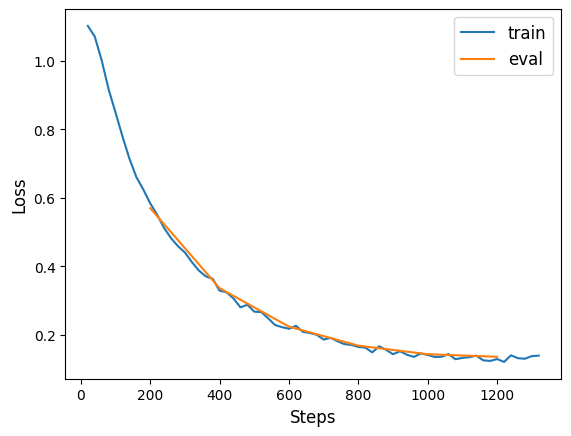

In [20]:
history = trainer.state.log_history
train_steps = [item["step"] for item in history if "loss" in item]
train_loss = [item["loss"] for item in history if "loss" in item]
eval_steps = [item["step"] for item in history if "eval_loss" in item]
eval_loss = [item["eval_loss"] for item in history if "eval_loss" in item]
train_log_loss = np.log(train_loss)
eval_log_loss = np.log(eval_loss)

plt.plot(train_steps, train_log_loss, label="train")
plt.plot(eval_steps, eval_log_loss, label="eval")
plt.xlabel("Steps", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(fontsize=12)
plt.show()

# 预测代码

In [16]:
def predict(messages, model, tokenizer):
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    model_inputs = tokenizer([text], return_tensors="pt").to("cuda")

    generated_ids = model.generate(
        model_inputs.input_ids,
        max_new_tokens=512
    )
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]     
    return response

In [18]:
# 用测试集的随机5条，测试模型
sample_test = test_df.sample(n=5)
for index, row in sample_test.iterrows():
    messages = [
        {"role": "system", "content": f"{PROMPT}"},
        {"role": "user", "content": f"{row['prompt']}"}
    ]
    response = predict(messages, model, tokenizer)
    messages.append({"role": "assistant", "content": f"{response}"})
    print(messages[1]['content'], "=>", messages[2]['content'])

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


类型#上衣*版型#显瘦*颜色#纯色*风格#文艺*风格#简约*图案#纯色*图案#撞色*衣样式#衬衫*衣领型#小立领*衣袖长#长袖*衣款式#纽扣 => 这件文艺简约风的纯色衬衫简直是日常穿搭的宝藏单品！显瘦的版型设计太懂女生啦，轻松藏起小肉肉，让身材线条更显纤细优雅～小立领搭配长袖，既保暖又不臃肿，春秋季节穿超舒服！纯色底色上点缀的撞色细节，打破单调感，让整体造型更有层次感，不管是配牛仔裤还是半身裙都超合适。经典纽扣设计简约大方，穿脱方便又耐穿，日常通勤、周末逛书店或咖啡馆都能轻松hold住！穿上它，既能展现文艺气质又能悄悄修饰身形，简约中透着精致，谁穿谁爱上这份清新与优雅，赶紧入手吧！
类型#上衣*颜色#纯色*风格#简约*图案#条纹*图案#纯色*衣样式#外套*衣款式#口袋*衣款式#对称 => 这件简约风的纯色条纹外套简直是日常穿搭的宝藏单品！经典的纯色基础搭配干净的条纹图案，简约中透着不经意的精致感，完全不张扬却足够吸睛～对称的设计细节让整体造型更显利落大方，贴心的口袋设计不仅实用，还能悄悄藏起小物件，让你随手拿着钥匙、手机都能轻松应对。不管是搭配牛仔裤还是半身裙，都能轻松穿出随性又时髦的范儿，日常出街、通勤或是周末逛街都超合适，穿上它舒适又好看，谁穿谁爱上这份简约与实用的美好！
类型#裤*材质#棉*材质#混纺*颜色#米白色*风格#清新*裤长#短裤*裤腰型#高腰 => 这条米白色高腰短裤简直是清新风的宝藏单品！精选棉混纺面料，柔软亲肤又透气，日常穿着舒适无束缚，夏天穿也不闷汗，完全不想脱下～高腰设计巧妙拉长腿部线条，轻松打造三七分好比例，小个子姐妹也能穿出大长腿感！经典的米白色调自带清新滤镜，不管是搭配简约T恤还是清爽衬衫，都能穿出元气满满的清新感，出街、约会或是日常通勤都超合适，穿上它你就是人群中最亮眼的清新少女，赶紧入手解锁你的夏日清新穿搭吧！
类型#上衣*风格#简约*衣样式#风衣*衣门襟#双排扣*衣款式#拼接*衣款式#绑带 => 这件简约风的风衣上衣简直是日常穿搭的宝藏单品！经典的双排扣门襟设计，不仅增添了几分利落感，还方便穿脱，让穿脱过程更省心~ 独特的拼接款式打破了单调感，让整体造型更具层次感与设计感；腰间的绑带细节更是点睛之笔，可自由调节松紧，轻松勾勒出纤细腰线，悄悄修饰身形，让你瞬间拥有小性感！不管是搭配牛仔裤通勤，还是配半身裙约会，都能轻松hold住，